<a href="https://colab.research.google.com/github/mariaalejandragg31-tech/Codigo1/blob/main/EDA_Portafolio_Matplotlib_Seaborn_yfinance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 📊 EDA de un portafolio de activos con Python
### Matplotlib · Seaborn · Pandas · yfinance

**Curso:** Lenguajes de programación  
**Tema:** Visualización y Análisis Exploratorio de Datos (EDA)  
**Caso:** análisis exploratorio de un portafolio de activos financieros

---

## 🎯 ¿Qué vamos a aprender?

Al terminar este notebook podrás:

- reconocer qué es una librería y para qué sirve;
- diferenciar **dato, variable, gráfico e interpretación**;
- crear gráficos básicos con **Matplotlib**;
- utilizar **Seaborn** para explorar distribuciones y relaciones;
- interpretar correctamente los gráficos;
- descargar datos históricos con **yfinance**;
- calcular rendimientos;
- explorar volatilidad, distribución y correlación;
- construir una primera lectura exploratoria de un portafolio.

> **Idea central:** un gráfico no es el resultado del análisis.  
> El gráfico es una herramienta que nos ayuda a **formular preguntas, encontrar patrones y comunicar hallazgos**.



## 🧭 Ruta de la clase

Trabajaremos de manera incremental:

**1. Datos → 2. Variables → 3. Gráfico → 4. Interpretación → 5. EDA → 6. Datos financieros reales**

| Etapa | Pregunta |
|---|---|
| Conceptos | ¿Qué estamos visualizando? |
| Matplotlib | ¿Cómo se construye un gráfico? |
| Seaborn | ¿Cómo exploramos una variable o relación? |
| EDA | ¿Qué patrones encontramos? |
| yfinance | ¿Cómo trabajamos con datos reales? |
| Portafolio | ¿Cómo se comportan conjuntamente los activos? |



# 1. Antes de graficar: pensemos como analistas

Supongamos que tenemos:

| Día | Precio |
|---:|---:|
| 1 | 100 |
| 2 | 103 |
| 3 | 101 |
| 4 | 108 |
| 5 | 112 |

Tenemos dos conceptos diferentes:

### Variable
Una característica que podemos observar o medir.  
Ejemplo: `Precio`.

### Observación
Un valor concreto de una variable.  
Ejemplo: el precio del día 4 es `108`.

### ¿Por qué graficar?

La tabla nos da los valores. El gráfico nos permite **ver la estructura de los datos**.

Por ejemplo:

- ¿el precio está aumentando?
- ¿hay caídas?
- ¿hay cambios bruscos?
- ¿existe una tendencia?

Ese proceso de preguntar, observar y encontrar patrones forma parte del **Análisis Exploratorio de Datos (EDA)**.



# 2. Las librerías que vamos a utilizar

Una **librería** es un conjunto de código reutilizable que otras personas han desarrollado para resolver problemas.

Hoy utilizaremos:

### 🐼 Pandas
Para trabajar con datos tabulares.

### 📈 Matplotlib
Para construir y personalizar visualizaciones.

### 🎨 Seaborn
Para crear visualizaciones estadísticas de forma sencilla y trabajar cómodamente con DataFrames.

### 💰 yfinance
Para obtener datos históricos de activos financieros desde Yahoo Finance.

La relación será:

```text
yfinance
   ↓
datos financieros
   ↓
Pandas
   ↓
transformaciones
   ↓
Matplotlib / Seaborn
   ↓
visualización
   ↓
interpretación
```


In [1]:
# Importamos las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual básica
sns.set_theme(style="whitegrid")

# Para que los gráficos aparezcan dentro del notebook
%matplotlib inline


## ¿Qué significa `import`?

Cuando escribimos:

```python
import matplotlib.pyplot as plt
```

estamos diciendo:

> "Quiero utilizar el módulo `pyplot` de la librería `matplotlib` y voy a llamarlo `plt`."

Por eso posteriormente podemos escribir:

```python
plt.plot(...)
```

El nombre `plt` es un **alias**. No es obligatorio llamarlo así, pero es una convención muy utilizada.

Lo mismo ocurre con:

```python
import seaborn as sns
import pandas as pd
import numpy as np
```



# 3. Nuestro primer gráfico: de una tabla a una visualización

Comencemos con datos muy pequeños para entender **qué hace cada instrucción**.

Tenemos el precio de un activo durante cinco días.


In [2]:
dias = [1, 2, 3, 4, 5]
precios = [100, 103, 101, 108, 112]

datos_ejemplo = pd.DataFrame({
    "Día": dias,
    "Precio": precios
})

datos_ejemplo

,Día,Precio
0,1,100
1,2,103
2,3,101
3,4,108
4,5,112



### Primer intento

Queremos representar:

- eje X → día
- eje Y → precio

La función `plot()` recibe normalmente una serie de valores para X y otra para Y.


In [ ]:
plt.plot(dias, precios)
plt.show()



## 🔎 ¿Qué acaba de ocurrir?

`plt.plot(x, y)`:

- toma los valores de `x`;
- toma los valores de `y`;
- coloca cada par `(x, y)` en el plano;
- conecta los puntos.

En nuestro ejemplo:

```text
(1,100)
(2,103)
(3,101)
(4,108)
(5,112)
```

### ¿Cómo lo interpretamos?

No debemos decir simplemente "el gráfico sube".

Podemos decir:

> **El precio presenta una tendencia general creciente durante el período observado, aunque existe una disminución entre los días 2 y 3.**

Esa segunda frase ya es una **interpretación**.



# 4. Hacer que el gráfico comunique mejor

Un gráfico debe permitir que otra persona entienda rápidamente:

1. **qué está viendo**;
2. **qué representan los ejes**;
3. **qué unidad se está utilizando**;
4. **qué período se está observando**.

Para eso agregamos título y etiquetas.


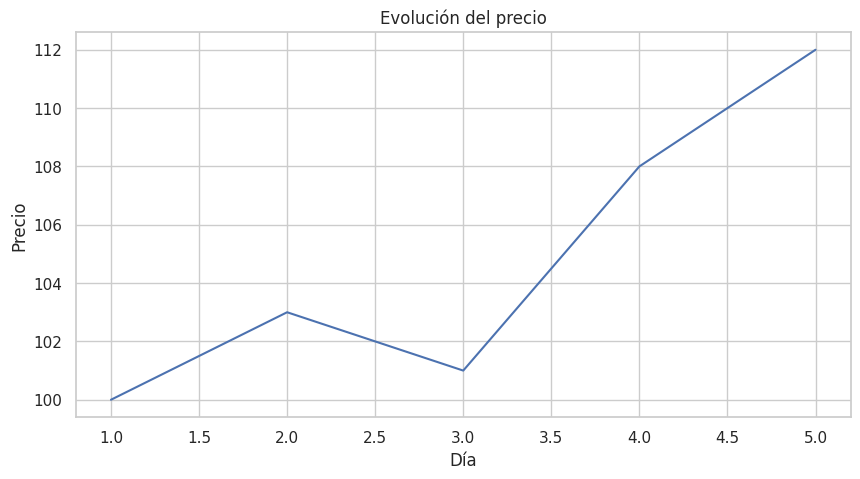

In [3]:
plt.figure(figsize=(10, 5))

plt.plot(dias, precios)

plt.title("Evolución del precio")
plt.xlabel("Día")
plt.ylabel("Precio")

plt.show()


## 🧩 Anatomía de un gráfico

```text
                 TÍTULO
        Evolución del precio

  Y
  ↑
  │             ●
  │          ●
  │     ●
  │        ●
  │  ●
  └──────────────────────→ X
       Día
```

### Elementos principales

- **Título:** comunica qué estamos observando.
- **Eje X:** normalmente representa tiempo o una variable explicativa.
- **Eje Y:** representa la variable que queremos analizar.
- **Línea/puntos:** representan los datos.
- **Leyenda:** identifica las series cuando tenemos varias.



# 5. La interfaz orientada a objetos de Matplotlib

Hasta ahora utilizamos `plt` directamente.

Existe otra forma muy importante:

```python
fig, ax = plt.subplots()
```

Aquí aparecen dos objetos:

### `fig`
Es la **figura completa**, el espacio donde estará nuestro gráfico.

### `ax`
Es el **área de ejes** donde realmente dibujamos.

Una forma sencilla de imaginarlo:

```text
Figure
┌─────────────────────────────┐
│                             │
│       Axes                  │
│     ┌───────────────┐       │
│     │   gráfico     │       │
│     │               │       │
│     └───────────────┘       │
│                             │
└─────────────────────────────┘
```


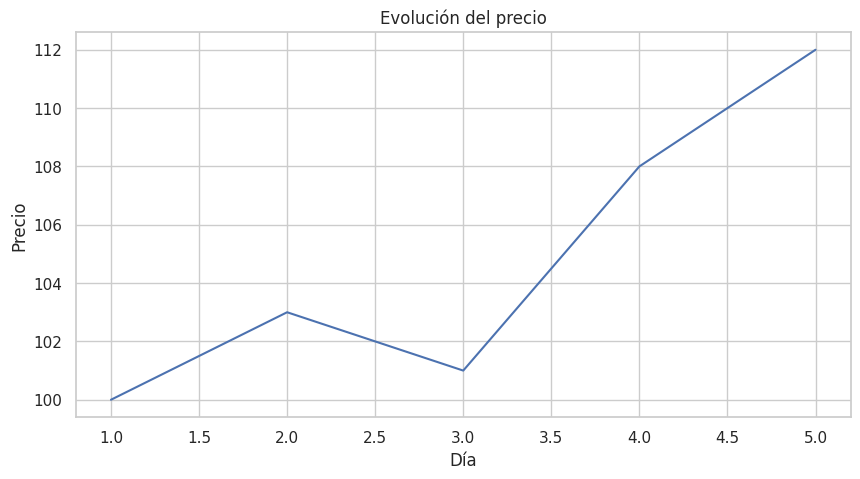

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(dias, precios)

ax.set_title("Evolución del precio")
ax.set_xlabel("Día")
ax.set_ylabel("Precio")

plt.show()


### ¿Por qué aprender esta forma?

Cuando los gráficos se vuelven más complejos, trabajar con `fig` y `ax` nos da mayor control.

Por ejemplo, podemos tener varios gráficos dentro de una misma figura y controlar cada eje por separado.

**Regla práctica para la clase:**

- `plt.plot()` → muy útil para comenzar.
- `fig, ax = plt.subplots()` → recomendable cuando queremos construir gráficos de forma más estructurada.



# 6. Gráficos de varias series

Ahora supongamos que tenemos tres activos.


In [5]:
precios_portafolio = pd.DataFrame({
    "AAPL": [100, 103, 101, 108, 112],
    "MSFT": [100, 102, 104, 106, 109],
    "NVDA": [100, 98, 105, 110, 120]
}, index=[1, 2, 3, 4, 5])

precios_portafolio

,AAPL,MSFT,NVDA
1,100,100,100
2,103,102,98
3,101,104,105
4,108,106,110
5,112,109,120



Si graficamos los precios directamente, podemos comparar las series.

Pero aparece un problema importante:

> ¿Cómo comparamos activos que originalmente tienen precios diferentes?

Por ahora nuestros datos comienzan todos en 100. Esto es intencional: queremos concentrarnos en la **forma de la serie** antes de introducir los rendimientos.


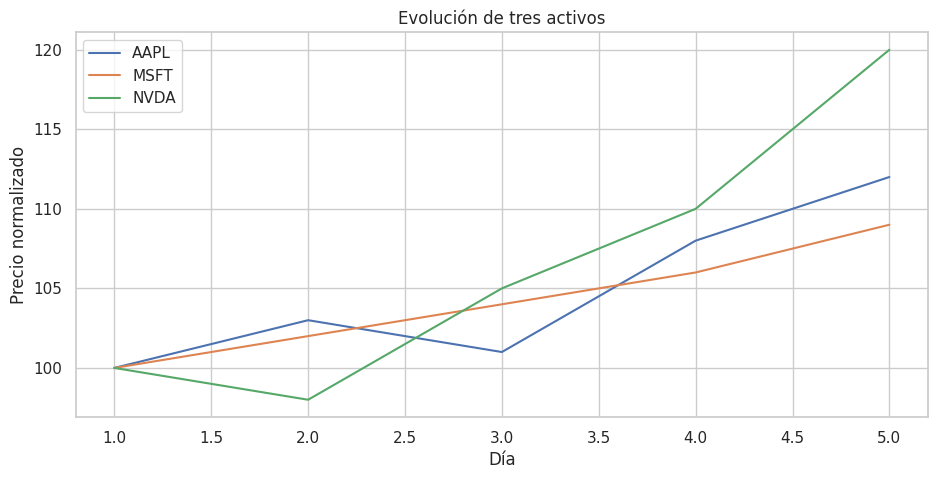

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(precios_portafolio.index, precios_portafolio["AAPL"], label="AAPL")
ax.plot(precios_portafolio.index, precios_portafolio["MSFT"], label="MSFT")
ax.plot(precios_portafolio.index, precios_portafolio["NVDA"], label="NVDA")

ax.set_title("Evolución de tres activos")
ax.set_xlabel("Día")
ax.set_ylabel("Precio normalizado")
ax.legend()

plt.show()


## 🧠 Interpretación

Observe primero, **después interprete**.

Preguntas:

1. ¿Cuál serie termina más arriba?
2. ¿Cuál presenta más cambios?
3. ¿Hay momentos en los que dos activos se mueven en direcciones diferentes?
4. ¿Podemos concluir cuál es "mejor" solamente con este gráfico?

La última pregunta es importante:

> **No.** Un gráfico puede mostrar comportamiento histórico, pero no convierte automáticamente ese comportamiento en una recomendación de inversión.



# 7. Seaborn: visualización orientada al análisis estadístico

Seaborn está construido sobre Matplotlib y facilita muchos gráficos estadísticos.

Una ventaja importante es que puede trabajar directamente con estructuras de Pandas.

Vamos a utilizar primero un **histograma**.


In [7]:
# Generamos una muestra sencilla de rendimientos

np.random.seed(42)

rendimientos_ejemplo = np.random.normal(
    loc=0.001,
    scale=0.02,
    size=500
)

rendimientos_ejemplo[:10]

array([ 0.01093428, -0.00176529,  0.01395377,  0.0314606 , -0.00368307,
       -0.00368274,  0.03258426,  0.01634869, -0.00838949,  0.0118512 ])


## ¿Qué pregunta responde un histograma?

Un histograma permite observar cómo se distribuyen los valores.

Por ejemplo:

> ¿En qué rango se concentran los rendimientos?


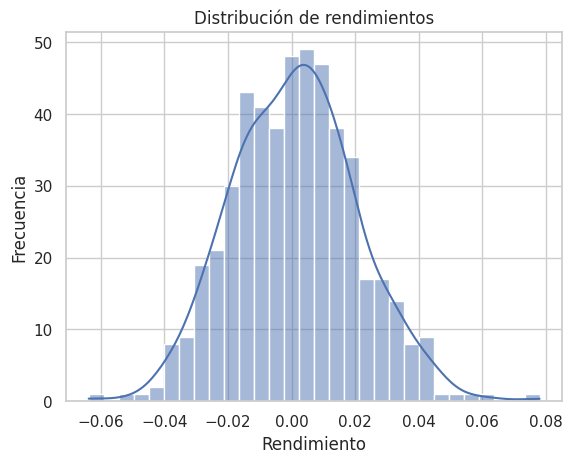

In [8]:
sns.histplot(
    rendimientos_ejemplo,
    bins=30,
    kde=True
)

plt.title("Distribución de rendimientos")
plt.xlabel("Rendimiento")
plt.ylabel("Frecuencia")

plt.show()


## 🔎 ¿Cómo interpretar un histograma?

Observemos:

### Centro
¿Dónde se concentran la mayoría de los valores?

### Dispersión
¿Qué tan extendidos están los datos?

### Colas
¿Hay valores alejados del centro?

### Forma
¿La distribución parece simétrica o presenta algún sesgo?

**Importante:** la forma del histograma depende de decisiones como el número de `bins`. No debemos interpretar cada detalle visual como una propiedad exacta de los datos.



# 8. Boxplot: detectar dispersión y valores extremos

Un boxplot resume visualmente una distribución.

Conceptualmente muestra:

- mediana;
- cuartiles;
- rango intercuartílico;
- posibles valores extremos.



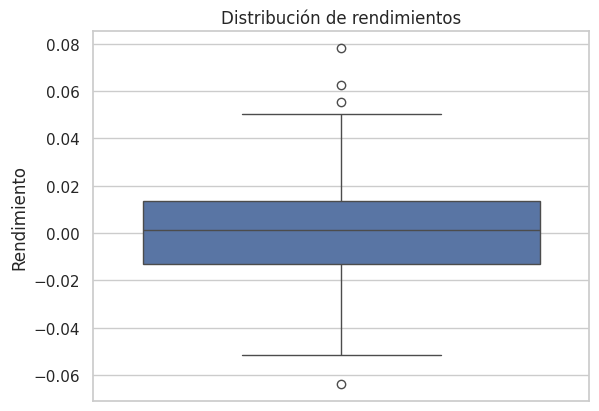

In [9]:
sns.boxplot(y=rendimientos_ejemplo)

plt.title("Distribución de rendimientos")
plt.ylabel("Rendimiento")

plt.show()


### Preguntas para interpretar

- ¿Dónde está la mediana?
- ¿Qué tan grande es la caja?
- ¿Qué tan largos son los bigotes?
- ¿Aparecen observaciones alejadas?

El objetivo no es memorizar la forma del dibujo.

El objetivo es poder decir:

> "La distribución presenta mayor/menor dispersión..."

y justificarlo a partir del gráfico.



# 9. Scatter plot: estudiar relaciones

Ahora queremos estudiar dos variables.

Por ejemplo:

> ¿Los cambios diarios de AAPL y MSFT tienden a ocurrir en la misma dirección?

Para eso usamos un **scatter plot**.

Cada punto representa una observación.


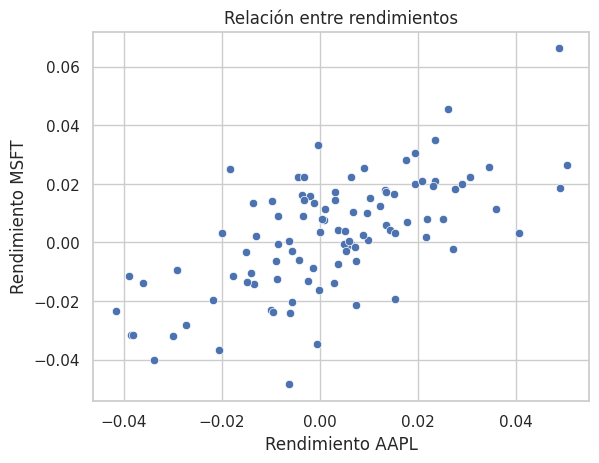

In [10]:
np.random.seed(10)

aapl = np.random.normal(0.001, 0.02, 100)
msft = aapl * 0.6 + np.random.normal(0, 0.015, 100)

sns.scatterplot(x=aapl, y=msft)

plt.title("Relación entre rendimientos")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()


## Interpretación

Buscamos patrones:

- nube ascendente → posible relación positiva;
- nube descendente → posible relación negativa;
- nube sin orientación clara → relación lineal débil o inexistente.

Pero recuerda:

> **Correlación no significa causalidad.**

Dos variables pueden moverse juntas sin que una sea la causa de la otra.



# 10. Correlación y mapa de calor

La correlación permite cuantificar la relación lineal entre dos variables.

En Python:

```python
df.corr()
```

produce una matriz de correlaciones.

Valores cercanos a:

- `1` → relación lineal positiva fuerte;
- `0` → relación lineal débil;
- `-1` → relación lineal negativa fuerte.

Veámoslo visualmente.


In [11]:
datos_rendimientos = pd.DataFrame({
    "AAPL": aapl,
    "MSFT": msft,
    "NVDA": aapl * 0.3 + np.random.normal(0, 0.025, 100)
})

correlacion = datos_rendimientos.corr()

correlacion

,AAPL,MSFT,NVDA
AAPL,1.000000,0.648544,0.207646
MSFT,0.648544,1.000000,0.205384
NVDA,0.207646,0.205384,1.000000


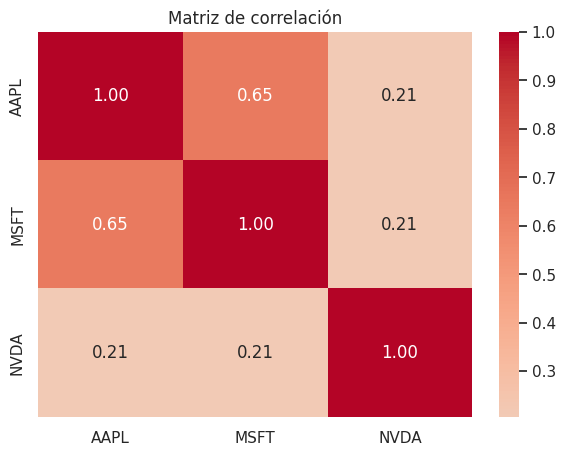

In [12]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlación")

plt.show()


## 🧠 Interpretar el heatmap

La matriz permite responder rápidamente:

> ¿Qué activos tienen comportamientos más similares?

Pero debemos tener cuidado:

- la correlación mide principalmente **relación lineal**;
- una correlación histórica no garantiza que se mantenga igual;
- correlación no significa causalidad;
- el período elegido afecta el resultado.

Para un análisis financiero serio también debemos considerar el período, frecuencia, calidad de datos y contexto del mercado.



# 11. Ahora sí: datos reales con yfinance 💰

Hasta este momento utilizamos datos pequeños o simulados para entender la visualización.

Ahora vamos a trabajar con datos reales.

Instalación, si el entorno todavía no tiene la librería:

```bash
pip install yfinance
```

Importamos:


In [13]:
import yfinance as yf


## ¿Qué activos vamos a estudiar?

Usaremos como ejemplo:

- `AAPL` — Apple
- `MSFT` — Microsoft
- `GOOGL` — Alphabet
- `AMZN` — Amazon
- `NVDA` — NVIDIA

Los símbolos son **tickers**, identificadores utilizados para localizar activos en los mercados.

> Los datos obtenidos mediante servicios externos pueden cambiar con el tiempo. Para una clase de EDA esto es útil: cada estudiante puede obtener una fotografía diferente del período consultado.


In [14]:
activos = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA"]

precios = yf.download(
    activos,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios.head()

[*********************100%***********************]  5 of 5 completed


Price            Close                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  183.404022  149.929993  136.867615  363.117920  48.028793   
2024-01-03  182.030716  148.470001  137.610550  362.853546  47.431515   
2024-01-04  179.718933  144.570007  135.104355  360.249115  47.859287   
2024-01-05  178.997726  145.240005  134.450577  360.063141  48.955112   
2024-01-08  183.324966  149.100006  137.531296  366.858093  52.101982   

Price             High                                                 ...  \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA  ...   
Date                                                                   ...   
2024-01-02  186.170300  152.380005  138.135548  368.042780  49.152535  ...   
2024-01-03  183.641087  151.050003  138.313864  365.457949  48.044735  ...   
2024-01-04  180.884713  147.380005  137.848248  365.301261  48.359835  ...   
2024-01-05  180.558698  146.589996  135.867105  364.283049  49.403813  ...   
2024-01-08  183.364493  149.399994  137.699692  367.357443  52.123922  ...   

Price             Open                                                 \
Ticker            AAPL        AMZN       GOOGL        MSFT       NVDA   
Date                                                                    
2024-01-02  184.895829  151.539993  137.244038  366.045412  49.101684   
2024-01-03  182.001078  149.199997  135.956293  361.296785  47.347758   
2024-01-04  179.956033  145.589996  137.115218  362.922062  47.628952   
2024-01-05  179.797983  144.690002  135.460966  361.257641  48.321949   
2024-01-08  179.896761  146.740005  135.005329  361.580743  49.368907   

Price         Volume                                           
Ticker          AAPL      AMZN     GOOGL      MSFT       NVDA  
Date                                                           
2024-01-02  82488700  47339400  23711200  25258600  411254000  
2024-01-03  58414500  49425500  24212100  23083500  320896000  
2024-01-04  71983600  56039800  27137700  20901500  306535000  
2024-01-05  62379700  45153100  22513900  21004600  415039000  
2024-01-08  59144500  46757100  21404000  23134000  642510000  

[5 rows x 25 columns]


# 12. Antes de graficar: conozcamos nuestros datos

Una regla fundamental de EDA:

> **No empieces a graficar sin conocer primero el DataFrame.**

Preguntas básicas:

- ¿cuántas filas tenemos?
- ¿cuántas columnas?
- ¿qué tipo de datos?
- ¿hay valores faltantes?
- ¿qué período cubren?


In [15]:
print("Dimensiones:", precios.shape)

precios.info()

Dimensiones: (502, 25)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 25 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, AAPL)    502 non-null    float64
 1   (Close, AMZN)    502 non-null    float64
 2   (Close, GOOGL)   502 non-null    float64
 3   (Close, MSFT)    502 non-null    float64
 4   (Close, NVDA)    502 non-null    float64
 5   (High, AAPL)     502 non-null    float64
 6   (High, AMZN)     502 non-null    float64
 7   (High, GOOGL)    502 non-null    float64
 8   (High, MSFT)     502 non-null    float64
 9   (High, NVDA)     502 non-null    float64
 10  (Low, AAPL)      502 non-null    float64
 11  (Low, AMZN)      502 non-null    float64
 12  (Low, GOOGL)     502 non-null    float64
 13  (Low, MSFT)      502 non-null    float64
 14  (Low, NVDA)      502 non-null    float64
 15  (Open, AAPL)     502 non-null    float64
 16  (Open, AMZN)     502

In [16]:
precios.describe()

Price        Close                                                  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA   
count   502.000000  502.000000  502.000000  502.000000  502.000000   
mean    218.163909  201.084920  186.196406  436.391723  130.434590   
std      29.061803   23.894482   44.695116   44.590887   36.478682   
min     163.220627  144.570007  130.161407  350.446106   47.431515   
25%     197.301437  182.045002  160.382675  404.577209  107.877951   
50%     220.355469  199.269997  171.818130  420.492249  129.622093   
75%     234.987221  223.067505  193.867241  475.532730  157.790546   
max     285.413116  254.000000  322.601013  537.646423  206.545166   

Price         High                                                  ...  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA  ...   
count   502.000000  502.000000  502.000000  502.000000  502.000000  ...   
mean    220.247259  203.257610  188.240374  439.904430  132.605679  ...   
std      29.157375   24.065589   45.248697   44.664828   36.763190  ...   
min     164.605523  146.589996  131.984083  360.250980   48.044735  ...   
25%     199.331459  184.752499  162.219168  407.837412  110.606060  ...   
50%     222.591303  200.525002  173.761174  423.625047  132.120719  ...   
75%     237.294614  225.872498  195.231441  480.116581  158.770635  ...   
max     287.836529  258.600006  327.977016  550.013114  211.682867  ...   

Price         Open                                                  \
Ticker        AAPL        AMZN       GOOGL        MSFT        NVDA   
count   502.000000  502.000000  502.000000  502.000000  502.000000   
mean    217.941191  201.160956  186.098552  436.394021  130.481370   
std      29.027179   24.115082   44.736023   44.931144   36.636462   
min     163.566856  144.690002  130.636902  346.808771   47.347758   
25%     196.633056  182.320004  160.184675  404.190582  107.114859   
50%     219.779643  199.305000  172.185869  420.292283  129.651093   
75%     234.190549  223.520004  192.999147  476.422511  157.940170   
max     285.423116  255.360001  325.363817  549.795235  207.582673   

Price         Volume                                                          
Ticker          AAPL          AMZN         GOOGL          MSFT          NVDA  
count   5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  5.020000e+02  
mean    5.564712e+07  4.270025e+07  3.183945e+07  2.138683e+07  2.992817e+08  
std     2.732569e+07  1.823593e+07  1.448971e+07  8.027734e+06  1.537611e+08  
min     1.791060e+07  1.142050e+07  1.009740e+07  5.855900e+06  6.552850e+07  
25%     4.132715e+07  3.153310e+07  2.236578e+07  1.632950e+07  1.841153e+08  
50%     4.890840e+07  3.871275e+07  2.853320e+07  1.958820e+07  2.505988e+08  
75%     6.041002e+07  4.680382e+07  3.582398e+07  2.359505e+07  3.779842e+08  
max     3.186799e+08  1.663408e+08  1.274901e+08  7.083610e+07  1.142269e+09  

[8 rows x 25 columns]

In [17]:
precios.isna().sum()

Price   Ticker
Close   AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
High    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Low     AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Open    AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
Volume  AAPL      0
        AMZN      0
        GOOGL     0
        MSFT      0
        NVDA      0
dtype: int64


### 🧪 Mini-reto

Antes de continuar, responde:

1. ¿Cuántas observaciones tenemos?
2. ¿Cuál es la primera fecha?
3. ¿Cuál es la última fecha?
4. ¿Existen valores faltantes?
5. ¿Qué representa cada nivel de columnas?

**No continúes hasta intentar responderlas.**



# 13. Seleccionar el precio de cierre

`yfinance` devuelve varias variables para cada activo, entre ellas:

- Open
- High
- Low
- Close
- Volume

Para nuestro primer análisis utilizaremos **Close**, el precio de cierre ajustado según la configuración utilizada.



In [18]:
cierre = precios["Close"]

cierre.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,183.404022,149.929993,136.867615,363.117920,48.028793
2024-01-03,182.030716,148.470001,137.610550,362.853546,47.431515
2024-01-04,179.718933,144.570007,135.104355,360.249115,47.859287
2024-01-05,178.997726,145.240005,134.450577,360.063141,48.955112
2024-01-08,183.324966,149.100006,137.531296,366.858093,52.101982



## Visualicemos los precios

Primera pregunta del EDA:

> **¿Cómo evolucionaron los precios de los activos durante el período?**


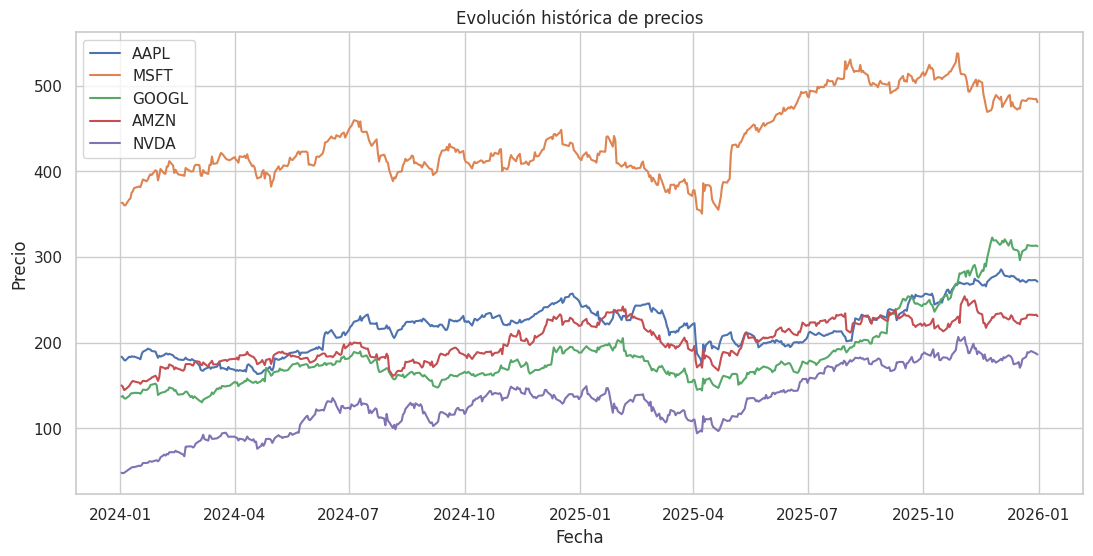

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(cierre.index, cierre[activo], label=activo)

ax.set_title("Evolución histórica de precios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio")
ax.legend()

plt.show()


## ⚠️ Una dificultad de comparar precios

AAPL puede tener un precio nominal diferente de NVDA, MSFT, etc.

Eso hace que comparar las alturas directamente pueda ser engañoso.

Una solución sencilla para estudiar **crecimiento relativo** es normalizar las series.

Por ejemplo:

```python
precio_normalizado = precio / precio_inicial * 100
```

Así todos comienzan en 100.


In [20]:
cierre_normalizado = cierre / cierre.iloc[0] * 100

cierre_normalizado.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,100.000000,100.000000,100.000000,100.000000,100.000000
2024-01-03,99.251213,99.026218,100.542813,99.927193,98.756416
2024-01-04,97.990726,96.425008,98.711704,99.209952,99.647074
2024-01-05,97.597492,96.871882,98.234032,99.158736,101.928675
2024-01-08,99.956895,99.446417,100.484907,101.030016,108.480723


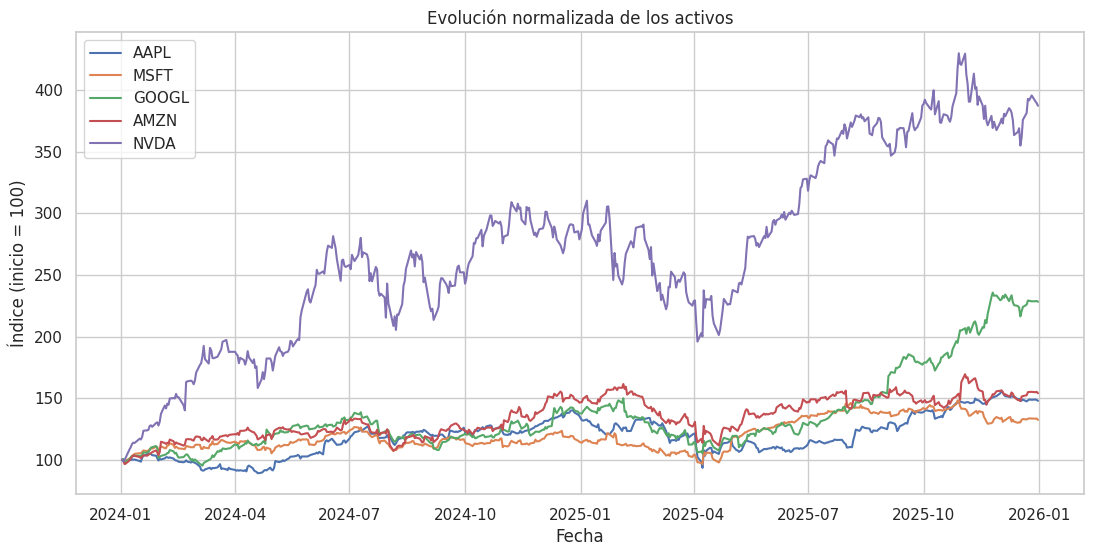

In [21]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        cierre_normalizado.index,
        cierre_normalizado[activo],
        label=activo
    )

ax.set_title("Evolución normalizada de los activos")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice (inicio = 100)")
ax.legend()

plt.show()


### ¿Qué pregunta responde este gráfico?

No responde:

> "¿Cuál tiene el precio más alto?"

Responde mejor:

> **"¿Cómo cambió cada activo respecto a su propio punto inicial?"**

Esta distinción es fundamental en análisis de datos financieros.



# 14. Rendimientos: transformar los precios

En análisis financiero suele ser útil estudiar **rendimientos** en lugar de precios.

Un rendimiento porcentual simple entre dos períodos puede calcularse como:

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

En Pandas podemos obtenerlo con:

```python
pct_change()
```


In [22]:
rendimientos = cierre.pct_change()

rendimientos.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-02,NaN,NaN,NaN,NaN,NaN
2024-01-03,-0.007488,-0.009738,0.005428,-0.000728,-0.012436
2024-01-04,-0.012700,-0.026268,-0.018212,-0.007178,0.009019
2024-01-05,-0.004013,0.004634,-0.004839,-0.000516,0.022897
2024-01-08,0.024175,0.026577,0.022913,0.018872,0.064281



El primer registro normalmente será `NaN` porque no tenemos un precio anterior con el cual compararlo.

Eliminemos esos valores para las visualizaciones que lo necesiten.


In [23]:
rendimientos = rendimientos.dropna()

rendimientos.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Date,,,,,
2024-01-03,-0.007488,-0.009738,0.005428,-0.000728,-0.012436
2024-01-04,-0.012700,-0.026268,-0.018212,-0.007178,0.009019
2024-01-05,-0.004013,0.004634,-0.004839,-0.000516,0.022897
2024-01-08,0.024175,0.026577,0.022913,0.018872,0.064281
2024-01-09,-0.002263,0.015225,0.015197,0.002936,0.016975



# 15. EDA de los rendimientos

### Pregunta 1
**¿Cómo se comportan los rendimientos a través del tiempo?**


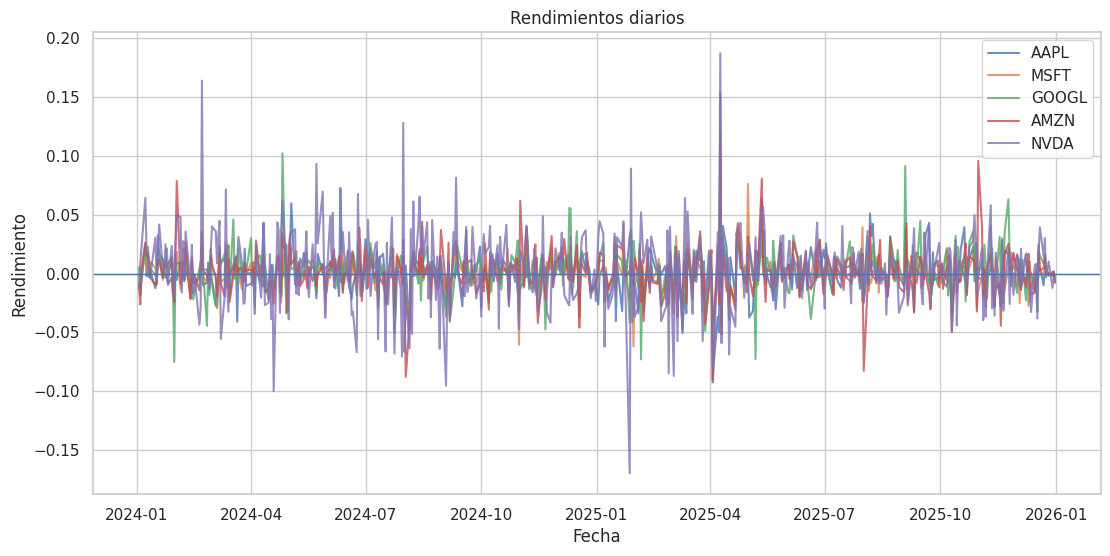

In [24]:
fig, ax = plt.subplots(figsize=(13, 6))

for activo in activos:
    ax.plot(
        rendimientos.index,
        rendimientos[activo],
        label=activo,
        alpha=0.8
    )

ax.axhline(0, linewidth=1)
ax.set_title("Rendimientos diarios")
ax.set_xlabel("Fecha")
ax.set_ylabel("Rendimiento")
ax.legend()

plt.show()


### Interpretación

La línea horizontal en cero nos ayuda a distinguir:

- valores positivos → rendimiento positivo;
- valores negativos → rendimiento negativo.

Busca:

- períodos de mayor variabilidad;
- movimientos extremos;
- momentos donde varios activos caen simultáneamente;
- diferencias entre activos.

**No confundas variabilidad con rendimiento.**

Un activo puede tener grandes movimientos hacia arriba y hacia abajo y terminar cerca del punto inicial.



# 16. Distribución de rendimientos

Ahora usamos Seaborn para estudiar una variable desde otro ángulo.

Pregunta:

> **¿Cómo se distribuyen los rendimientos diarios de cada activo?**


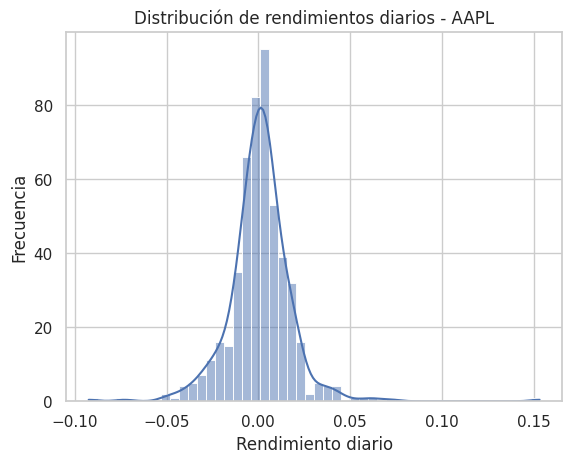

In [25]:
sns.histplot(
    data=rendimientos,
    x="AAPL",
    bins=50,
    kde=True
)

plt.title("Distribución de rendimientos diarios - AAPL")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")

plt.show()


## 🧪 Cambia el activo

Modifica `"AAPL"` por:

```python
"MSFT"
"GOOGL"
"AMZN"
"NVDA"
```

### Pregunta

¿Qué diferencias observas entre las distribuciones?

No busques solamente cuál "se ve mejor".

Describe:

- centro;
- dispersión;
- valores extremos;
- forma de la distribución.



# 17. Comparar la dispersión con un boxplot

Ahora podemos comparar todos los activos simultáneamente.


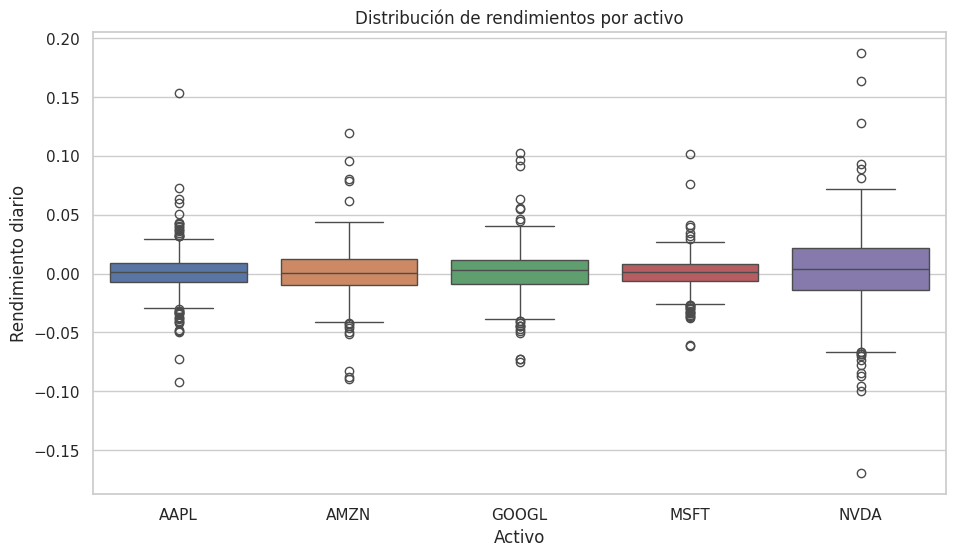

In [26]:
plt.figure(figsize=(11, 6))

sns.boxplot(data=rendimientos)

plt.title("Distribución de rendimientos por activo")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")

plt.show()


### Preguntas de análisis

1. ¿Qué activos muestran mayor dispersión?
2. ¿Qué activos presentan más observaciones alejadas?
3. ¿Las medianas están cerca de cero?
4. ¿Qué información perderíamos si solo observáramos el precio?

Aquí aparece una idea importante:

> **Una buena visualización permite comparar una propiedad concreta de los datos.**



# 18. Matriz de correlación del portafolio

Ahora llegamos a una de las visualizaciones más importantes para nuestro caso.

Pregunta:

> **¿Cómo se relacionan los rendimientos de los activos entre sí?**


In [27]:
correlacion = rendimientos.corr()

correlacion

Ticker,AAPL,AMZN,GOOGL,MSFT,NVDA
Ticker,,,,,
AAPL,1.000000,0.484033,0.442987,0.479061,0.350518
AMZN,0.484033,1.000000,0.540440,0.625640,0.505377
GOOGL,0.442987,0.540440,1.000000,0.485902,0.398910
MSFT,0.479061,0.625640,0.485902,1.000000,0.549244
NVDA,0.350518,0.505377,0.398910,0.549244,1.000000


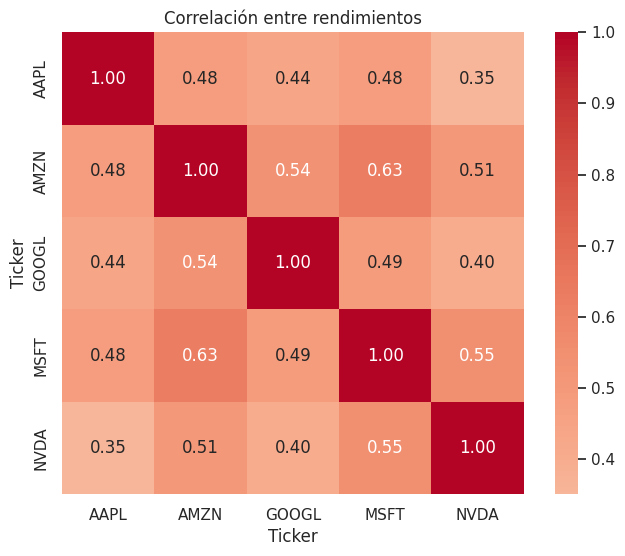

In [28]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Correlación entre rendimientos")

plt.show()


## 🧠 ¿Cómo leer la matriz?

Supongamos que encontramos:

```text
             AAPL    MSFT
AAPL          1.00   0.70
MSFT          0.70   1.00
```

La diagonal es 1 porque cada activo está perfectamente correlacionado consigo mismo.

Un valor de `0.70` indica una relación lineal positiva relativamente alta en el período analizado.

### Pregunta de portafolio

Si dos activos presentan una correlación elevada:

> ¿Qué implica esto para la diversificación?

Una posible interpretación es que **pueden proporcionar menos diversificación entre sí que dos activos con una correlación menor**, aunque la diversificación real depende de muchos otros factores.

No debemos convertir la correlación, por sí sola, en una recomendación de inversión.



# 19. Scatter plot: profundicemos en una pareja

Seleccionemos dos activos:

```python
AAPL
MSFT
```

Cada punto representa un día.

- X → rendimiento de AAPL
- Y → rendimiento de MSFT



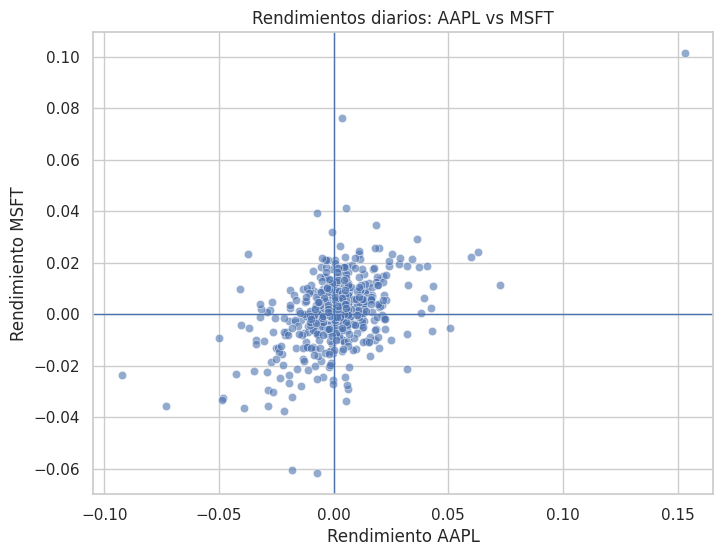

In [29]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=rendimientos,
    x="AAPL",
    y="MSFT",
    alpha=0.6
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.title("Rendimientos diarios: AAPL vs MSFT")
plt.xlabel("Rendimiento AAPL")
plt.ylabel("Rendimiento MSFT")

plt.show()


### Preguntas para interpretar

Observa la nube de puntos:

1. ¿Existe una orientación ascendente?
2. ¿Qué ocurre cuando AAPL tiene rendimiento negativo?
3. ¿MSFT suele tener el mismo signo?
4. ¿Hay valores extremos?
5. ¿La relación parece perfectamente lineal?

El scatter plot y la matriz de correlación están contando historias relacionadas, pero desde perspectivas diferentes:

**Scatter → vemos las observaciones individuales.**  
**Correlación → resumimos numéricamente la relación lineal.**



# 20. Estadísticas descriptivas del portafolio

La visualización debe complementarse con medidas numéricas.



In [30]:
resumen = pd.DataFrame({
    "Media": rendimientos.mean(),
    "Mediana": rendimientos.median(),
    "Desviación estándar": rendimientos.std(),
    "Mínimo": rendimientos.min(),
    "Máximo": rendimientos.max()
})

resumen

,Media,Mediana,Desviación estándar,Mínimo,Máximo
Ticker,,,,,
AAPL,0.000933,0.001187,0.017571,-0.092456,0.153289
AMZN,0.001056,0.000648,0.019781,-0.089791,0.119770
GOOGL,0.001829,0.002923,0.019062,-0.075003,0.102244
MSFT,0.000657,0.001111,0.013975,-0.061809,0.101337
NVDA,0.003222,0.003503,0.032181,-0.169682,0.187227



## ¿Qué estamos viendo?

### Media
Promedio de los rendimientos.

### Mediana
Valor central de la distribución.

### Desviación estándar
Medida de dispersión utilizada frecuentemente como una aproximación de la volatilidad histórica.

### Mínimo / máximo
Permiten observar los extremos registrados en el período.

**Importante:** estas estadísticas describen el período analizado. No garantizan que el futuro se comporte igual.



# 21. Mini-proyecto: EDA completo

Ahora debes construir tu propio análisis.

## Objetivo

Selecciona entre **3 y 5 activos** y realiza un EDA.

### Paso 1 — Datos

Descarga los datos históricos.

### Paso 2 — Calidad

Revisa:

- dimensiones;
- tipos;
- valores faltantes;
- período.

### Paso 3 — Precios

Construye un gráfico de evolución de precios.

### Paso 4 — Normalización

Construye un gráfico con todas las series comenzando en 100.

### Paso 5 — Rendimientos

Calcula los rendimientos diarios.

### Paso 6 — Distribución

Construye un histograma para uno de los activos.

### Paso 7 — Comparación

Construye un boxplot de los rendimientos.

### Paso 8 — Relación

Construye una matriz de correlación.

### Paso 9 — Relación entre dos activos

Construye un scatter plot.

### Paso 10 — Conclusiones

Escribe **3 hallazgos**.

Cada hallazgo debe tener esta estructura:

> **Gráfico:** ¿qué gráfico utilizaste?  
> **Observación:** ¿qué ves?  
> **Interpretación:** ¿qué significa esa observación para el análisis?



# 22. Reto final 🎯

Sin modificar el código inicialmente:

### Pregunta 1
¿Cuál activo presenta mayor dispersión de rendimientos?

### Pregunta 2
¿Cuáles dos activos presentan mayor correlación?

### Pregunta 3
¿Cuáles presentan menor correlación?

### Pregunta 4
¿Existe algún día donde varios activos tengan movimientos extremos simultáneamente?

### Pregunta 5
¿La evolución normalizada cuenta la misma historia que los precios originales?

### Pregunta 6
¿Qué información aporta el histograma que no aporta el gráfico temporal?

### Pregunta 7
¿Qué información aporta el scatter plot que no aporta el heatmap?

---

## ⭐ Regla de oro del EDA

Antes de hacer un gráfico pregunta:

> **¿Qué quiero saber?**

Después del gráfico pregunta:

> **¿Qué estoy observando?**

Y finalmente:

> **¿Qué puedo concluir razonablemente a partir de lo observado?**



# 📚 Referencias

- [Matplotlib — documentación oficial](https://matplotlib.org/stable/)
- [Matplotlib — galería de ejemplos](https://matplotlib.org/stable/gallery/)
- [Matplotlib — introducción a Figure y Axes](https://matplotlib.org/stable/users/explain/figure/figure_intro.html)
- [Seaborn — documentación oficial](https://seaborn.pydata.org/)
- [Pandas — visualización](https://pandas.pydata.org/docs/user_guide/visualization.html)
- [yfinance — documentación](https://ranaroussi.github.io/yfinance/)

### Nota sobre los datos

Los datos obtenidos mediante `yfinance` corresponden a información histórica de mercado y pueden cambiar dependiendo del período consultado, ajustes y disponibilidad. Este notebook tiene finalidad educativa y de análisis de datos; no constituye asesoría financiera.


# 21. Mini-proyecto: EDA propio

Para no repetir los activos utilizados en los ejemplos anteriores, este análisis utiliza cuatro activos diferentes:

- `TSLA` — Tesla
- `META` — Meta Platforms
- `JPM` — JPMorgan Chase
- `KO` — Coca-Cola

**Período:** 2024-01-01 a 2026-01-01.


## Paso 1 — Datos

Descargamos los datos históricos de los cuatro activos seleccionados.

In [31]:
activos_proyecto = ["TSLA", "META", "JPM", "KO"]

precios_proyecto = yf.download(
    activos_proyecto,
    start="2024-01-01",
    end="2026-01-01",
    auto_adjust=True
)

precios_proyecto.head()

[*********************100%***********************]  4 of 4 completed


Price            Close                                           High  \
Ticker             JPM         KO        META        TSLA         JPM   
Date                                                                    
2024-01-02  162.278320  55.309341  343.004822  248.419998  162.363190   
2024-01-03  161.571014  55.438778  341.202087  238.449997  162.240565   
2024-01-04  162.643219  55.253857  343.826965  237.929993  164.484000   
2024-01-05  163.459213  55.170639  348.611145  237.490005  164.512443   
2024-01-08  163.222015  55.577469  355.257477  240.449997  163.544623   

Price                                                 Low             \
Ticker             KO        META        TSLA         JPM         KO   
Date                                                                   
2024-01-02  55.364818  349.809643  251.250000  159.288885  54.246054   
2024-01-03  55.660683  344.649084  245.679993  160.665690  55.253858   
2024-01-04  55.716155  344.847193  242.699997  161.817705  55.161398   
2024-01-05  55.429528  350.146428  240.119995  162.700127  54.634375   
2024-01-08  55.642190  355.574448  241.250000  160.821414  54.939495   

Price                                     Open                         \
Ticker            META        TSLA         JPM         KO        META   
Date                                                                    
2024-01-02  336.784400  244.410004  159.458626  54.366253  347.987102   
2024-01-03  339.924317  236.320007  162.070824  55.411041  341.707259   
2024-01-04  340.142255  237.729996  161.912597  55.521990  341.231825   
2024-01-05  342.975122  234.899994  162.700127  55.290838  343.698178   
2024-01-08  348.710169  235.300003  163.222015  55.179892  351.335053   

Price                     Volume                                 
Ticker            TSLA       JPM        KO      META       TSLA  
Date                                                             
2024-01-02  250.080002   9977400  16322600  19042200  104654200  
2024-01-03  244.979996   9852300  14830600  15451100  121082600  
2024-01-04  239.250000  11972500  12912900  12099900  102629300  
2024-01-05  236.860001  10066000  10412800  13920700   92488900  
2024-01-08  236.139999  11229900  11554600  13890200   85166600

## Paso 2 — Calidad

Revisamos dimensiones, tipos, valores faltantes y período.

In [32]:
print("Dimensiones:", precios_proyecto.shape)
print("\nPrimera fecha:", precios_proyecto.index.min())
print("Última fecha:", precios_proyecto.index.max())
print("\nInformación del DataFrame:")
precios_proyecto.info()
print("\nValores faltantes:")
print(precios_proyecto.isna().sum())

Dimensiones: (502, 20)

Primera fecha: 2024-01-02 00:00:00
Última fecha: 2025-12-31 00:00:00

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 502 entries, 2024-01-02 to 2025-12-31
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, JPM)    502 non-null    float64
 1   (Close, KO)     502 non-null    float64
 2   (Close, META)   502 non-null    float64
 3   (Close, TSLA)   502 non-null    float64
 4   (High, JPM)     502 non-null    float64
 5   (High, KO)      502 non-null    float64
 6   (High, META)    502 non-null    float64
 7   (High, TSLA)    502 non-null    float64
 8   (Low, JPM)      502 non-null    float64
 9   (Low, KO)       502 non-null    float64
 10  (Low, META)     502 non-null    float64
 11  (Low, TSLA)     502 non-null    float64
 12  (Open, JPM)     502 non-null    float64
 13  (Open, KO)      502 non-null    float64
 14  (Open, META)    502 non-null  

## Paso 3 — Precios

Observamos la evolución de los precios de cierre.

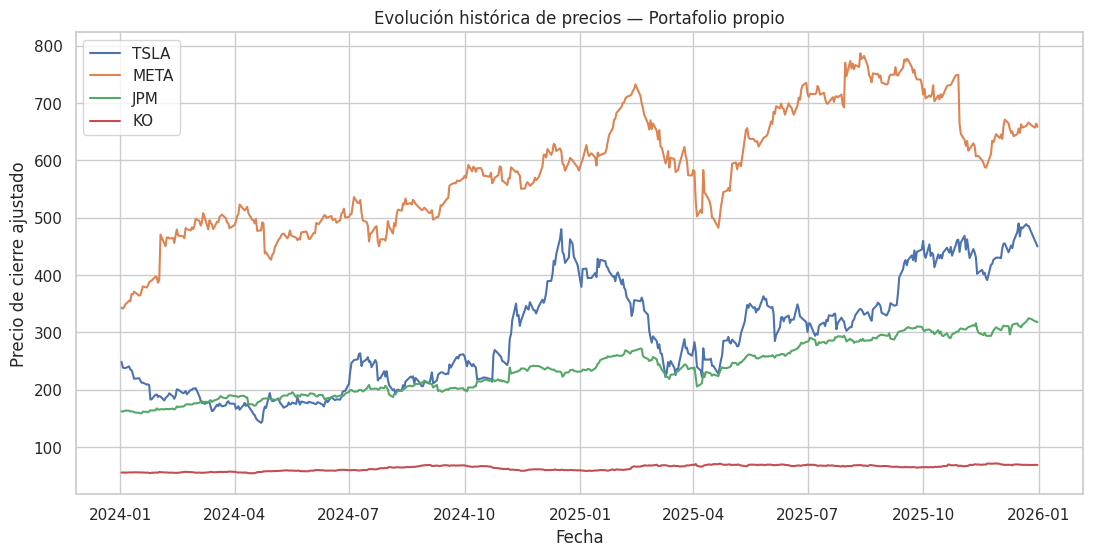

In [33]:
cierre_proyecto = precios_proyecto["Close"]

fig, ax = plt.subplots(figsize=(13, 6))
for activo in activos_proyecto:
    ax.plot(cierre_proyecto.index, cierre_proyecto[activo], label=activo)

ax.set_title("Evolución histórica de precios — Portafolio propio")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio de cierre ajustado")
ax.legend()
plt.show()

## Paso 4 — Normalización

Llevamos todas las series a una base inicial de 100 para comparar su evolución relativa.

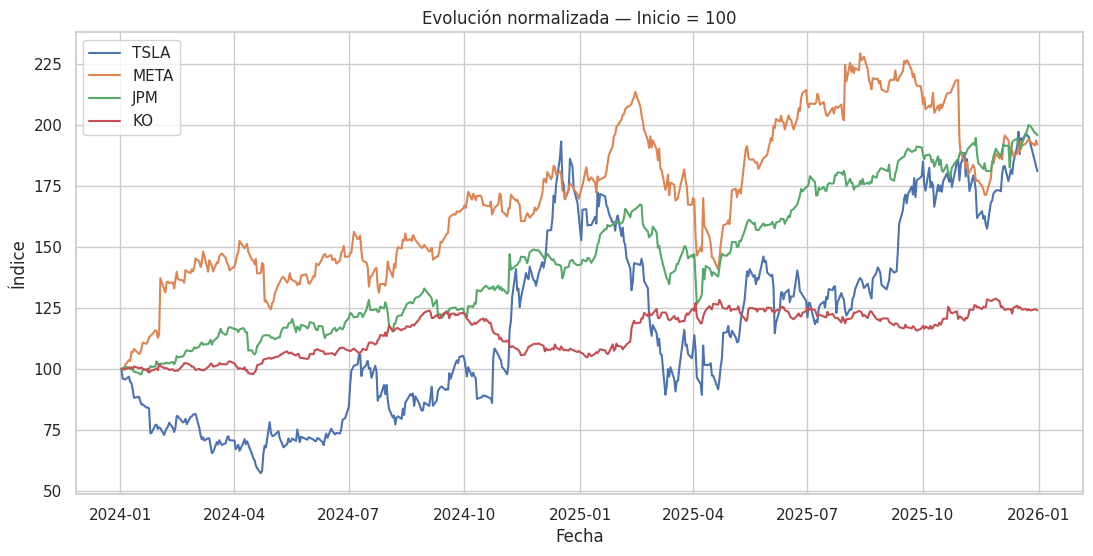

In [34]:
cierre_normalizado_proyecto = cierre_proyecto / cierre_proyecto.iloc[0] * 100

fig, ax = plt.subplots(figsize=(13, 6))
for activo in activos_proyecto:
    ax.plot(cierre_normalizado_proyecto.index,
            cierre_normalizado_proyecto[activo],
            label=activo)

ax.set_title("Evolución normalizada — Inicio = 100")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice")
ax.legend()
plt.show()

## Paso 5 — Rendimientos

Calculamos los rendimientos porcentuales diarios.

In [35]:
rendimientos_proyecto = cierre_proyecto.pct_change().dropna()
rendimientos_proyecto.head()

Ticker,JPM,KO,META,TSLA
Date,,,,
2024-01-03,-0.004359,0.002340,-0.005256,-0.040134
2024-01-04,0.006636,-0.003336,0.007693,-0.002181
2024-01-05,0.005017,-0.001506,0.013914,-0.001849
2024-01-08,-0.001451,0.007374,0.019065,0.012464
2024-01-09,-0.007906,-0.001830,-0.003429,-0.022832


## Paso 6 — Distribución

Analizamos la distribución de los rendimientos diarios de TSLA.

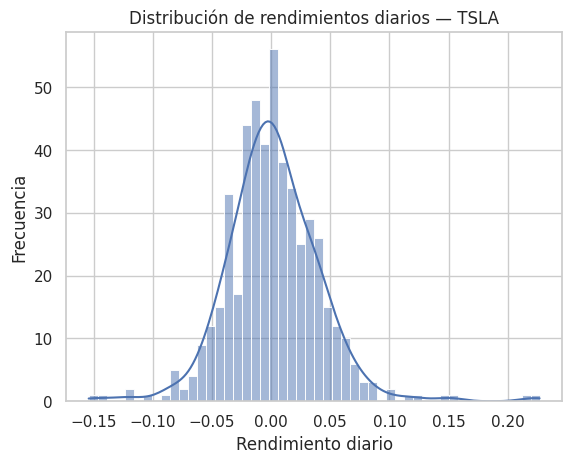

In [36]:
sns.histplot(data=rendimientos_proyecto, x="TSLA", bins=50, kde=True)
plt.title("Distribución de rendimientos diarios — TSLA")
plt.xlabel("Rendimiento diario")
plt.ylabel("Frecuencia")
plt.show()

## Paso 7 — Comparación

Comparamos la dispersión de los rendimientos mediante un boxplot.

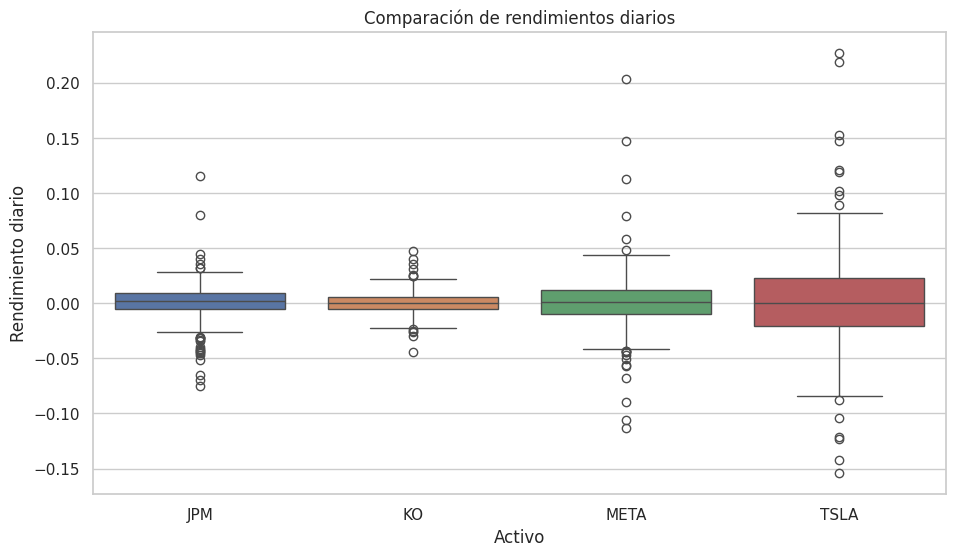

In [37]:
plt.figure(figsize=(11, 6))
sns.boxplot(data=rendimientos_proyecto)
plt.title("Comparación de rendimientos diarios")
plt.xlabel("Activo")
plt.ylabel("Rendimiento diario")
plt.show()

## Paso 8 — Relación

Calculamos la matriz de correlación y la mostramos mediante un heatmap.

Matriz de correlación:


Ticker,JPM,KO,META,TSLA
Ticker,,,,
JPM,1.000000,0.065968,0.296957,0.368614
KO,0.065968,1.000000,-0.100065,-0.093175
META,0.296957,-0.100065,1.000000,0.335655
TSLA,0.368614,-0.093175,0.335655,1.000000


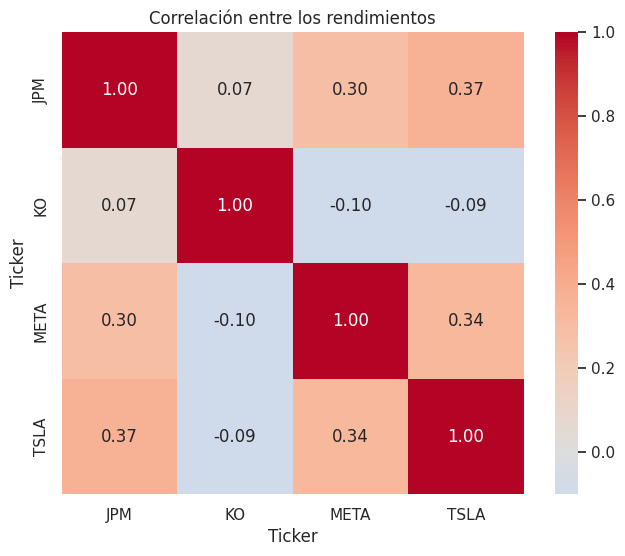

In [38]:
correlacion_proyecto = rendimientos_proyecto.corr()

print("Matriz de correlación:")
display(correlacion_proyecto)

plt.figure(figsize=(8, 6))
sns.heatmap(correlacion_proyecto, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True)
plt.title("Correlación entre los rendimientos")
plt.show()

## Paso 9 — Relación entre dos activos

Comparamos TSLA y JPM mediante un gráfico de dispersión.

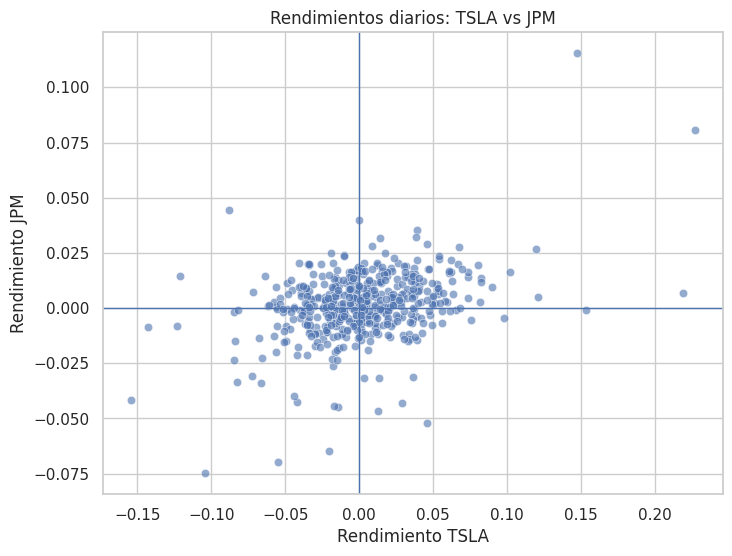

In [39]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=rendimientos_proyecto, x="TSLA", y="JPM", alpha=0.6)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Rendimientos diarios: TSLA vs JPM")
plt.xlabel("Rendimiento TSLA")
plt.ylabel("Rendimiento JPM")
plt.show()

## Paso 10 — Conclusiones

Los siguientes cálculos identifican hallazgos directamente a partir de nuestro portafolio.

In [40]:
desviacion_proyecto = rendimientos_proyecto.std()
activo_mayor_dispersion = desviacion_proyecto.idxmax()

mascara_superior = np.triu(np.ones(correlacion_proyecto.shape, dtype=bool), k=1)
correlaciones_parejas = correlacion_proyecto.where(mascara_superior).stack()

pareja_mayor = correlaciones_parejas.idxmax()
mayor_correlacion = correlaciones_parejas.max()
pareja_menor = correlaciones_parejas.idxmin()
menor_correlacion = correlaciones_parejas.min()

activo_mayor_evolucion = cierre_normalizado_proyecto.iloc[-1].idxmax()
valor_mayor_evolucion = cierre_normalizado_proyecto.iloc[-1].max()

print("HALLAZGO 1")
print("Gráfico: Boxplot")
print(f"Observación: {activo_mayor_dispersion} tiene la mayor dispersión ({desviacion_proyecto[activo_mayor_dispersion]:.4f}).")
print("Interpretación: presenta la mayor variabilidad de rendimientos diarios en el período.")

print("\nHALLAZGO 2")
print("Gráfico: Heatmap")
print(f"Observación: {pareja_mayor[0]} y {pareja_mayor[1]} tienen la mayor correlación ({mayor_correlacion:.2f}).")
print("Interpretación: sus rendimientos presentan la relación lineal conjunta más fuerte del grupo.")

print("\nHALLAZGO 3")
print("Gráfico: Evolución normalizada")
print(f"Observación: {activo_mayor_evolucion} termina con el mayor índice ({valor_mayor_evolucion:.2f}).")
print("Interpretación: tuvo la mayor evolución relativa desde una base común de 100.")

HALLAZGO 1
Gráfico: Boxplot
Observación: TSLA tiene la mayor dispersión (0.0400).
Interpretación: presenta la mayor variabilidad de rendimientos diarios en el período.

HALLAZGO 2
Gráfico: Heatmap
Observación: JPM y TSLA tienen la mayor correlación (0.37).
Interpretación: sus rendimientos presentan la relación lineal conjunta más fuerte del grupo.

HALLAZGO 3
Gráfico: Evolución normalizada
Observación: JPM termina con el mayor índice (195.78).
Interpretación: tuvo la mayor evolución relativa desde una base común de 100.


# 22. Reto final 🎯

Las respuestas siguientes se obtienen usando nuestro propio portafolio: TSLA, META, JPM y KO.


### 1. ¿Qué activo tiene mayor dispersión de rendimientos?

In [41]:
print("Activo con mayor dispersión:", activo_mayor_dispersion)
print("Desviación estándar:", round(desviacion_proyecto[activo_mayor_dispersion], 4))

Activo con mayor dispersión: TSLA
Desviación estándar: 0.04


### 2. ¿Qué dos activos tienen mayor correlación?

In [42]:
print("Pareja con mayor correlación:", pareja_mayor)
print("Correlación:", round(mayor_correlacion, 4))

Pareja con mayor correlación: ('JPM', 'TSLA')
Correlación: 0.3686


### 3. ¿Qué activos tienen menor correlación?

In [43]:
print("Pareja con menor correlación:", pareja_menor)
print("Correlación:", round(menor_correlacion, 4))

Pareja con menor correlación: ('KO', 'META')
Correlación: -0.1001


### 4. ¿Existe un día donde varios activos tengan movimientos extremos simultáneamente?

In [44]:
umbral_extremo = rendimientos_proyecto.abs().stack().quantile(0.95)
extremos = rendimientos_proyecto.abs() >= umbral_extremo
dias_extremos = extremos.sum(axis=1)
dias_varios_extremos = dias_extremos[dias_extremos >= 2]

print("Umbral de movimiento extremo:", round(umbral_extremo, 4))
print("\nDías con dos o más activos en movimiento extremo:")
display(dias_varios_extremos)

Umbral de movimiento extremo: 0.049

Días con dos o más activos en movimiento extremo:


,0
Date,
2024-04-25,2
2024-07-24,2
2024-11-06,2
2025-04-03,3
2025-04-04,3
2025-04-09,3
2025-04-10,2
2025-05-12,2


### 5. ¿La evolución normalizada cuenta la misma historia que los precios originales?

No necesariamente. Los precios originales muestran valores monetarios absolutos; la normalización permite comparar la evolución relativa de todos los activos desde una misma base de 100.


### 6. ¿Qué información da el histograma que el gráfico temporal no muestra?

El gráfico temporal muestra cuándo ocurrieron las subidas y bajadas. El histograma muestra cómo se distribuyeron los rendimientos: concentración, dispersión, frecuencia y posibles valores extremos.


### 7. ¿Qué información da el scatter plot que el heatmap no muestra?

El heatmap resume la correlación mediante valores numéricos. El scatter plot muestra cada observación diaria como un punto y permite ver la tendencia, concentración y posibles valores extremos entre los dos activos.
